In [46]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

✓ Loaded A2C (5%): 30 episodes
✓ Loaded LFU (5%): 100 episodes
✓ Loaded LRU (5%): 100 episodes
✓ Loaded FIFO (5%): 100 episodes
✓ Loaded A2C (10%): 35 episodes
✓ Loaded LFU (10%): 100 episodes
✓ Loaded LRU (10%): 100 episodes
✓ Loaded FIFO (10%): 100 episodes
✓ Loaded A2C (15%): 30 episodes
✓ Loaded LFU (15%): 100 episodes
✓ Loaded LRU (15%): 100 episodes
✓ Loaded FIFO (15%): 100 episodes
✓ Loaded A2C (20%): 66 episodes
✓ Loaded LFU (20%): 100 episodes
✓ Loaded LRU (20%): 100 episodes
✓ Loaded FIFO (20%): 100 episodes

[INFO] Generating multi-scenario grouped bar chart...


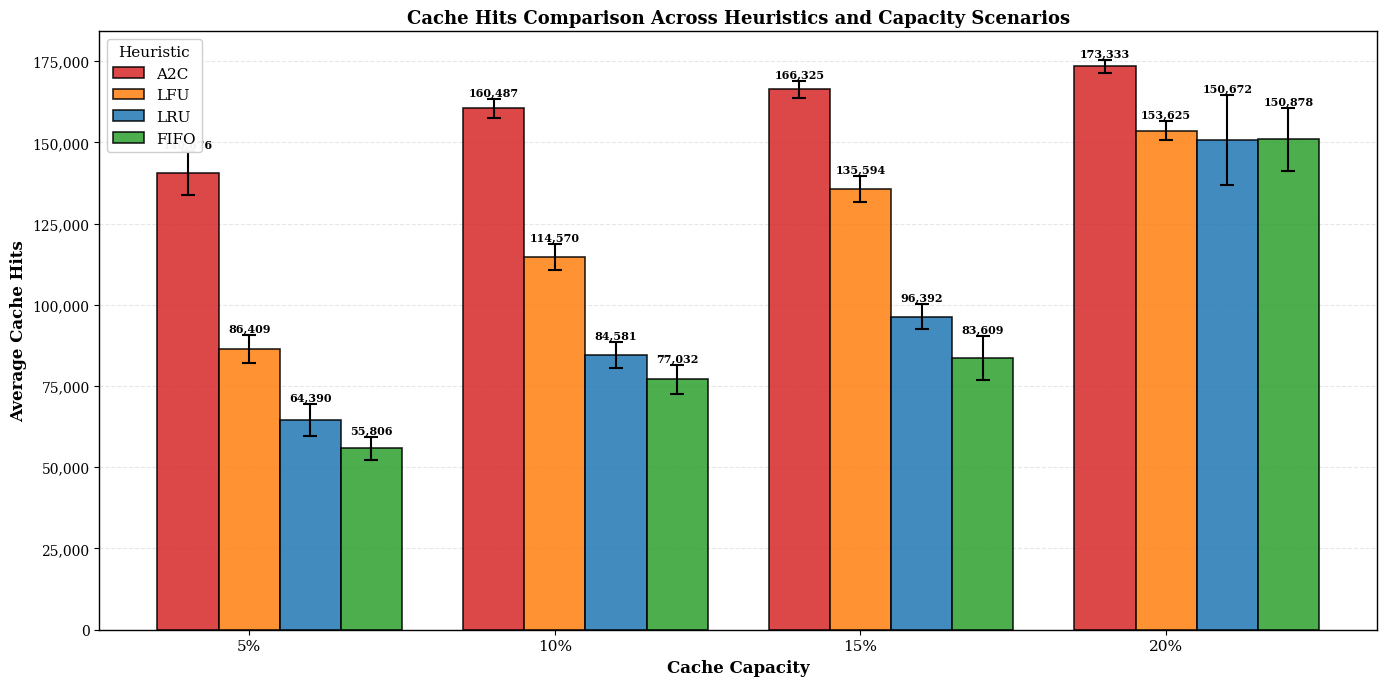


[INFO] Generating trend lines...


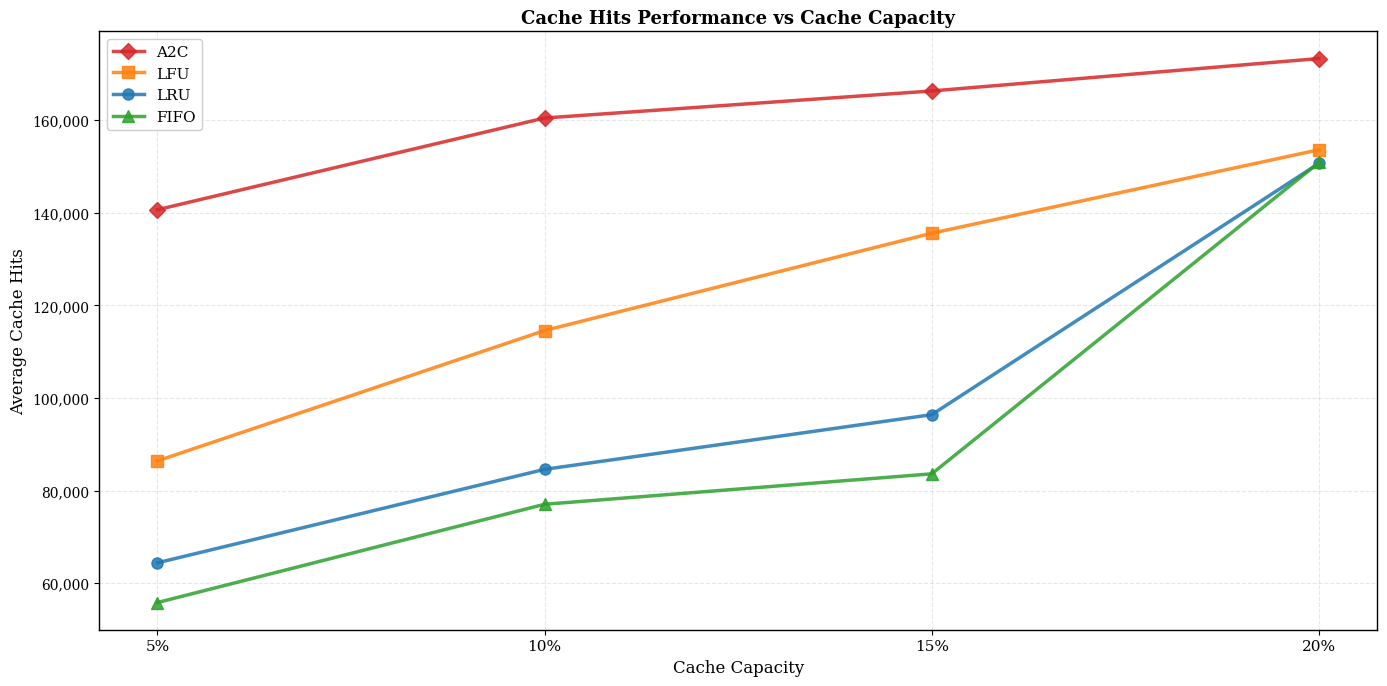


[INFO] Printing summary statistics...

MULTI-SCENARIO CACHE HEURISTICS COMPARISON SUMMARY

------------------------------------------------------------------------------------------
CACHE CAPACITY: 5%
------------------------------------------------------------------------------------------

A2C:
  Avg Cache Hits per Episode: 140,676
  Total Cache Hits: 4,220,286
  Avg Cache Misses per Episode: 47,606
  Avg Hit Rate: 74.72%

FIFO:
  Avg Cache Hits per Episode: 55,806
  Total Cache Hits: 5,580,648
  Avg Cache Misses per Episode: 132,850
  Avg Hit Rate: 29.58%

LFU:
  Avg Cache Hits per Episode: 86,409
  Total Cache Hits: 8,640,934
  Avg Cache Misses per Episode: 102,247
  Avg Hit Rate: 45.80%

LRU:
  Avg Cache Hits per Episode: 64,390
  Total Cache Hits: 6,438,969
  Avg Cache Misses per Episode: 124,266
  Avg Hit Rate: 34.13%

------------------------------------------------------------------------------------------
CACHE CAPACITY: 10%
--------------------------------------------------

In [5]:
# Multi-Scenario Comparison: Heuristics across different cache capacities

# Define heuristics and their result directories for different cache capacities


CAPACITY_SCENARIOS = {
    '5%': {
        'A2C': os.path.join('..', 'Results', '2026-05-11_10-53'),
        'LFU': os.path.join('..', 'Results', '2026-05-11_09-42'),
        'LRU': os.path.join('..', 'Results', '2026-05-11_09-33'),
        'FIFO': os.path.join('..', 'Results', '2026-05-11_10-01'),
    },
    '10%': {
        'A2C': os.path.join('..', 'Results', '2026-05-11_11-10'),
        'LFU': os.path.join('..', 'Results', '2026-05-11_09-44'),
        'LRU': os.path.join('..', 'Results', '2026-05-11_09-35'),
        'FIFO': os.path.join('..', 'Results', '2026-05-11_10-12'),
    },
    '15%': {
        'A2C': os.path.join('..', 'Results', '2026-05-11_11-31'),
        'LFU': os.path.join('..', 'Results', '2026-05-11_09-47'),
        'LRU': os.path.join('..', 'Results', '2026-05-11_09-37'),
        'FIFO': os.path.join('..', 'Results', '2026-05-11_10-32'),
    },
    '20%': {
        'A2C': os.path.join('..', 'Results', '2026-05-11_11-46'),
        'LFU': os.path.join('..', 'Results', '2026-05-11_09-50'),
        'LRU': os.path.join('..', 'Results', '2026-05-11_09-40'),
        'FIFO': os.path.join('..', 'Results', '2026-05-11_10-38'),
    },
}

def load_multi_scenario_metrics(capacity_scenarios: dict, metrics_file: str = 'metrics/episode_metrics.csv'):
    """Load cache metrics for each heuristic across all capacity scenarios."""
    loaded_data = {}
    
    for capacity, heuristics in capacity_scenarios.items():
        loaded_data[capacity] = {}
        for heuristic_name, result_dir in heuristics.items():
            csv_path = os.path.join(result_dir, metrics_file)
            
            if not os.path.exists(csv_path):
                print(f"[WARN] Missing file for {heuristic_name} ({capacity}): {csv_path}")
                continue
            
            try:
                df = pd.read_csv(csv_path)
                loaded_data[capacity][heuristic_name] = df
                print(f"✓ Loaded {heuristic_name} ({capacity}): {len(df)} episodes")
            except Exception as e:
                print(f"[ERROR] Failed to load {heuristic_name} ({capacity}): {e}")
    
    return loaded_data

def plot_heuristics_by_capacity(capacity_scenarios_data: dict, figsize=(14, 7)):
    """Plot cache hits as grouped bars: capacities on x-axis, heuristics as groups."""
    
    # Set up publication-quality style
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "legend.fontsize": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 10,
        "axes.linewidth": 1.0,
        "lines.linewidth": 2.0,
    })
    
    fig, ax = plt.subplots(figsize=figsize)
    
    capacities = sorted(capacity_scenarios_data.keys(), key=lambda x: int(x.rstrip('%')))
    heuristics = list(capacity_scenarios_data[capacities[0]].keys())
    
    colors = {'LFU': '#ff7f0e', 'LRU': '#1f77b4', 'FIFO': '#2ca02c', 'A2C': '#d62728'}
    
    # Prepare data for grouped bar chart
    x = np.arange(len(capacities))
    width = 0.2  # Width of each bar
    
    # Store bar containers for value labels
    all_bars = []
    all_vals = []
    all_stds = []
    
    for idx, heuristic in enumerate(heuristics):
        avg_hits = []
        std_hits = []
        
        for capacity in capacities:
            if heuristic in capacity_scenarios_data[capacity]:
                df = capacity_scenarios_data[capacity][heuristic]
                avg_hits.append(df['cache_hits'].mean())
                std_hits.append(df['cache_hits'].std())
            else:
                avg_hits.append(0)
                std_hits.append(0)

        # Position bars for this heuristic
        offset = width * (idx - 1)
        bars = ax.bar(
            x + offset, 
            avg_hits, 
            width,
            yerr=std_hits,
            label=heuristic,
            color=colors.get(heuristic, '#7f7f7f'),
            alpha=0.85,
            capsize=5,
            edgecolor='black',
            linewidth=1.2,
            error_kw={'elinewidth': 1.5, 'capthick': 1.5}
        )
        
        all_bars.append(bars)
        all_vals.append(avg_hits)
        all_stds.append(std_hits)
    
    # Add value labels on top of each bar
    for bars, vals, stds in zip(all_bars, all_vals, all_stds):
        for bar, val, std in zip(bars, vals, stds):
            if val > 0:  # Only label non-empty bars
                ax.text(
                    bar.get_x() + bar.get_width() / 2, 
                    val + std + 500,
                    f'{val:,.0f}',
                    ha='center', 
                    va='bottom',
                    fontsize=8,
                    fontweight='bold'
                )
    
    # Customize axes
    ax.set_xlabel('Cache Capacity', fontsize=12, fontweight='bold')
    ax.set_ylabel('Average Cache Hits', fontsize=12, fontweight='bold')
    ax.set_title('Cache Hits Comparison Across Heuristics and Capacity Scenarios', 
                 fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(capacities)
    ax.legend(loc='upper left', framealpha=0.95, title='Heuristic', fontsize=11)
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    ax.set_axisbelow(True)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
    
    plt.tight_layout()
    plt.savefig('heuristics_capacity_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return fig, ax

def plot_heuristics_line_by_capacity(capacity_scenarios_data: dict, figsize=(14, 7)):
    """Plot average cache hits as lines for each heuristic across capacity scenarios."""

    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "legend.fontsize": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 10,
        "axes.linewidth": 1.0,
        "lines.linewidth": 2.5,
    })

    fig, ax = plt.subplots(figsize=figsize)

    capacities = sorted(capacity_scenarios_data.keys(), key=lambda x: int(x.rstrip('%')))
    heuristics = list(capacity_scenarios_data[capacities[0]].keys())
    
    colors = { 'A2C': '#d62728', 'LRU': '#1f77b4', 'LFU': '#ff7f0e', 'FIFO': '#2ca02c'}
    markers = {'LFU': 's', 'LRU': 'o', 'FIFO': '^', 'A2C': 'D'}
    
    # Prepare data for each heuristic
    for heuristic in heuristics:
        avg_hits_list = []
        
        for capacity in capacities:
            if heuristic in capacity_scenarios_data[capacity]:
                df = capacity_scenarios_data[capacity][heuristic]
                avg_hits_list.append(df['cache_hits'].mean())
            else:
                avg_hits_list.append(None)
        
        # Plot line for this heuristic
        ax.plot(
            capacities,
            avg_hits_list,
            label=heuristic,
            linewidth=2.5,
            color=colors.get(heuristic),
            marker=markers.get(heuristic),
            markersize=8,
            alpha=0.85
        )
    
    ax.set_xlabel('Cache Capacity', fontsize=12)
    ax.set_ylabel('Average Cache Hits', fontsize=12)
    ax.set_title('Cache Hits Performance vs Cache Capacity', fontsize=13, fontweight='bold')
    ax.legend(loc='best', framealpha=0.95)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
    
    plt.tight_layout()
    plt.savefig('heuristics_capacity_trends.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return fig, ax

def print_multi_scenario_summary(capacity_scenarios_data: dict):
    """Print summary statistics for each heuristic across all capacity scenarios."""
    print("\n" + "="*90)
    print("MULTI-SCENARIO CACHE HEURISTICS COMPARISON SUMMARY")
    print("="*90)
    
    capacities = sorted(capacity_scenarios_data.keys(), key=lambda x: int(x.rstrip('%')))
    
    for capacity in capacities:
        print(f"\n{'-'*90}")
        print(f"CACHE CAPACITY: {capacity}")
        print(f"{'-'*90}")
        
        for heuristic_name, df in sorted(capacity_scenarios_data[capacity].items()):
            avg_hits = df['cache_hits'].mean()
            total_hits = df['cache_hits'].sum()
            avg_misses = df['cache_misses'].mean()
            avg_hit_rate = df['hit_rate'].mean() * 100
            
            print(f"\n{heuristic_name}:")
            print(f"  Avg Cache Hits per Episode: {avg_hits:,.0f}")
            print(f"  Total Cache Hits: {total_hits:,.0f}")
            print(f"  Avg Cache Misses per Episode: {avg_misses:,.0f}")
            print(f"  Avg Hit Rate: {avg_hit_rate:.2f}%")

# Load data and plot multi-scenario comparison
capacity_scenarios_data = load_multi_scenario_metrics(CAPACITY_SCENARIOS)

if capacity_scenarios_data:
    print("\n[INFO] Generating multi-scenario grouped bar chart...")
    plot_heuristics_by_capacity(capacity_scenarios_data)
    
    print("\n[INFO] Generating trend lines...")
    plot_heuristics_line_by_capacity(capacity_scenarios_data)
    
    print("\n[INFO] Printing summary statistics...")
    print_multi_scenario_summary(capacity_scenarios_data)
else:
    print("[ERROR] No multi-scenario data loaded. Please update CAPACITY_SCENARIOS paths.")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✓ Loaded A2C (5%): 72 episodes
✓ Loaded LFU (5%): 100 episodes
✓ Loaded LRU (5%): 100 episodes
✓ Loaded FIFO (5%): 100 episodes
✓ Loaded A2C (10%): 30 episodes
✓ Loaded LFU (10%): 100 episodes
✓ Loaded LRU (10%): 100 episodes
✓ Loaded FIFO (10%): 100 episodes
✓ Loaded A2C (15%): 30 episodes
✓ Loaded LFU (15%): 100 episodes
✓ Loaded LRU (15%): 100 episodes
✓ Loaded FIFO (15%): 100 episodes
✓ Loaded A2C (20%): 86 episodes
✓ Loaded LFU (20%): 100 episodes
✓ Loaded LRU (20%): 100 episodes
✓ Loaded FIFO (20%): 100 episodes

[INFO] Generating multi-scenario grouped bar chart...


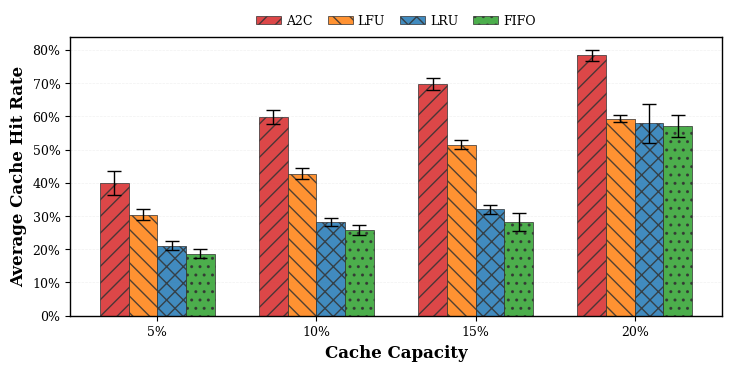

In [51]:
# Multi-Scenario Comparison: Heuristics across different cache capacities

# Define heuristics and their result directories for different cache capacities
CAPACITY_SCENARIOS = {
    '5%': {
        'A2C': os.path.join('..', 'Results', '2026-05-11_14-01'),
        'LFU': os.path.join('..', 'Results', '2026-05-11_13-07'),
        'LRU': os.path.join('..', 'Results', '2026-05-11_12-22'),
        'FIFO': os.path.join('..', 'Results', '2026-05-11_13-18'),
    },
    '10%': {
        'A2C': os.path.join('..', 'Results', '2026-05-11_14-35'),
        'LFU': os.path.join('..', 'Results', '2026-05-11_13-10'),
        'LRU': os.path.join('..', 'Results', '2026-05-11_12-27'),
        'FIFO': os.path.join('..', 'Results', '2026-05-11_13-22'),
    },
    '15%': {
        'A2C': os.path.join('..', 'Results', '2026-05-11_14-50'),
        'LFU': os.path.join('..', 'Results', '2026-05-11_13-12'),
        'LRU': os.path.join('..', 'Results', '2026-05-11_12-28'),
        'FIFO': os.path.join('..', 'Results', '2026-05-11_13-25'),
    },
    '20%': {
        'A2C': os.path.join('..', 'Results', '2026-05-11_15-04'),
        'LFU': os.path.join('..', 'Results', '2026-05-11_13-15'),
        'LRU': os.path.join('..', 'Results', '2026-05-11_12-36'),
        'FIFO': os.path.join('..', 'Results', '2026-05-11_13-28'),
    },
}

def load_multi_scenario_metrics(capacity_scenarios: dict, metrics_file: str = 'metrics/episode_metrics.csv'):
    """Load cache metrics for each heuristic across all capacity scenarios."""
    loaded_data = {}

    for capacity, heuristics in capacity_scenarios.items():
        loaded_data[capacity] = {}
        for heuristic_name, result_dir in heuristics.items():
            csv_path = os.path.join(result_dir, metrics_file)

            if not os.path.exists(csv_path):
                print(f"[WARN] Missing file for {heuristic_name} ({capacity}): {csv_path}")
                continue

            try:
                df = pd.read_csv(csv_path)
                loaded_data[capacity][heuristic_name] = df
                print(f"✓ Loaded {heuristic_name} ({capacity}): {len(df)} episodes")
            except Exception as e:
                print(f"[ERROR] Failed to load {heuristic_name} ({capacity}): {e}")

    return loaded_data

def plot_heuristics_by_capacity(capacity_scenarios_data: dict, figsize=(7.2, 3.6)):
    """Plot cache hit rate as grouped bars: capacities on x-axis, heuristics as groups."""

    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 11,
        "legend.fontsize": 9,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    })

    capacities = sorted(capacity_scenarios_data.keys(), key=lambda x: int(x.rstrip('%')))
    heuristics = list(capacity_scenarios_data[capacities[0]].keys())
    colors = {'LFU': '#ff7f0e', 'LRU': '#1f77b4', 'FIFO': '#2ca02c', 'A2C': '#d62728'}
    hatches = ['//', '\\\\', 'xx', '..']
    
    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

    x = np.arange(len(capacities))
    width = 0.18 if len(heuristics) >= 4 else 0.22

    for idx, heuristic in enumerate(heuristics):
        avg_chr = []
        std_chr = []

        for capacity in capacities:
            if heuristic in capacity_scenarios_data[capacity]:
                df = capacity_scenarios_data[capacity][heuristic]
                avg_chr.append(df['chr'].mean())
                std_chr.append(df['chr'].std())
            else:
                avg_chr.append(np.nan)
                std_chr.append(0)

        offset = width * (idx - (len(heuristics) - 1) / 2)
        bars = ax.bar(
            x + offset,
            avg_chr,
            width,
            yerr=std_chr,
            label=heuristic,
            color=colors.get(heuristic, '#7f7f7f'),
            alpha=0.85,
            capsize=5,
            edgecolor='0.2',
            linewidth=0.6,
            error_kw={'elinewidth': 1.0, 'capthick': 1.0},
            hatch=hatches[idx],
        )

        # for bar, val, std in zip(bars, avg_chr, std_chr):
        #     if pd.notna(val):
        #         ax.text(
        #             bar.get_x() + bar.get_width() / 2,
        #             val + (std if pd.notna(std) else 0) + 0.01,
        #             f'{val:.0%}',
        #             ha='center',
        #             va='bottom',
        #             fontsize=8,
        #             fontweight='bold',
        #         )

    ax.set_xlabel('Cache Capacity', fontsize=12, fontweight='bold')
    ax.set_ylabel('Average Cache Hit Rate', fontsize=12, fontweight='bold')
    # ax.set_title('Cache Hit Rate Comparison Across Heuristics and Capacity Scenarios', fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(capacities)
    # ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.18), ncol=len(heuristics), frameon=False, title='Heuristic')
    ax.legend(
        ncol=len(heuristics),
        frameon=False,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.12),
        columnspacing=1.2,
        handletextpad=0.4
    )
    ax.grid(True, alpha=0.18, linewidth=0.5, axis='y', linestyle='--')
    ax.set_axisbelow(True)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, position: f'{value:.0%}'))

    plt.savefig('chr_comparison.eps', bbox_inches='tight')
    plt.show()

    return fig, ax

# Load data and plot multi-scenario comparison
capacity_scenarios_data = load_multi_scenario_metrics(CAPACITY_SCENARIOS)

if capacity_scenarios_data:
    print("\n[INFO] Generating multi-scenario grouped bar chart...")
    plot_heuristics_by_capacity(capacity_scenarios_data)
else:
    print("[ERROR] No multi-scenario data loaded. Please update CAPACITY_SCENARIOS paths.")


[INFO] Generating multi-scenario grouped bar chart...


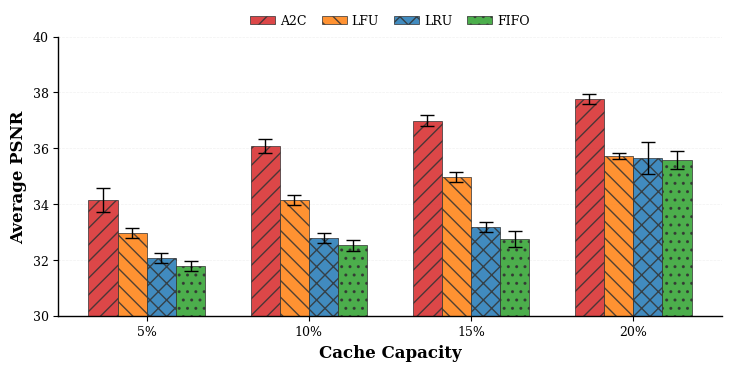

In [40]:
def plot_heuristics_by_capacity(capacity_scenarios_data: dict, figsize=(7.2, 3.6)):
    """Plot cache hit rate as grouped bars: capacities on x-axis, heuristics as groups."""

    # plt.rcParams.update({
    #     "font.family": "serif",
    #     "font.size": 11,
    #     "axes.labelsize": 12,
    #     "axes.titlesize": 13,
    #     "legend.fontsize": 11,
    #     "xtick.labelsize": 11,
    #     "ytick.labelsize": 10,
    #     "axes.linewidth": 1.0,
    #     "lines.linewidth": 2.0,
    # })
    
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 11,
        "legend.fontsize": 9,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    })

    capacities = sorted(capacity_scenarios_data.keys(), key=lambda x: int(x.rstrip('%')))
    heuristics = list(capacity_scenarios_data[capacities[0]].keys())
    colors = {'LFU': '#ff7f0e', 'LRU': '#1f77b4', 'FIFO': '#2ca02c', 'A2C': '#d62728'}
    hatches = ['//', '\\\\', 'xx', '..']

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

    x = np.arange(len(capacities))
    width = 0.18 if len(heuristics) >= 4 else 0.22

    for idx, heuristic in enumerate(heuristics):
        avg_chr = []
        std_chr = []

        for capacity in capacities:
            if heuristic in capacity_scenarios_data[capacity]:
                df = capacity_scenarios_data[capacity][heuristic]
                avg_chr.append(df['psnr'].mean())
                std_chr.append(df['psnr'].std())
            else:
                avg_chr.append(np.nan)
                std_chr.append(0)

        offset = width * (idx - (len(heuristics) - 1) / 2)
        
        
        bars = ax.bar(
            x + offset,
            avg_chr,
            width,
            yerr=std_chr,
            label=heuristic,
            color=colors.get(heuristic, '#7f7f7f'),
            alpha=0.85,
            capsize=5,
            edgecolor='0.2',
            linewidth=0.6,
            error_kw={'elinewidth': 1.0, 'capthick': 1.0},
            hatch=hatches[idx],
        )

        # for bar, val, std in zip(bars, avg_chr, std_chr):
        #     if pd.notna(val):
        #         ax.text(
        #             bar.get_x() + bar.get_width() / 2,
        #             val + (std if pd.notna(std) else 0) + 0.01,
        #             f'{val:.0f}',
        #             ha='center',
        #             va='bottom',
        #             fontsize=8,
        #             fontweight='bold',
        #         )

    ax.set_xlabel('Cache Capacity', fontsize=12, fontweight='bold')
    ax.set_ylabel('Average PSNR', fontsize=12, fontweight='bold')
    # ax.set_title('PSNR Comparison Across Heuristics and Capacity Scenarios', fontsize=13, fontweight='bold')
    ax.set_ylim(30, 40)
    ax.set_xticks(x)
    ax.set_xticklabels(capacities)
    # ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1), ncol=len(heuristics), frameon=False)
    ax.legend(
        ncol=len(heuristics),
        frameon=False,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.12),
        columnspacing=1.2,
        handletextpad=0.4
    )
        
    ax.grid(True, alpha=0.18, linewidth=0.5, axis='y', linestyle='--')
    ax.set_axisbelow(True)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, position: f'{value:.0f}'))

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.savefig('psnr_comparison.png', bbox_inches='tight')
    plt.show()

    return fig, ax

if capacity_scenarios_data:
    print("\n[INFO] Generating multi-scenario grouped bar chart...")
    plot_heuristics_by_capacity(capacity_scenarios_data)
else:
    print("[ERROR] No multi-scenario data loaded. Please update CAPACITY_SCENARIOS paths.")


A2C TRAINING DYNAMICS ANALYSIS

Analyzing 5% capacity...


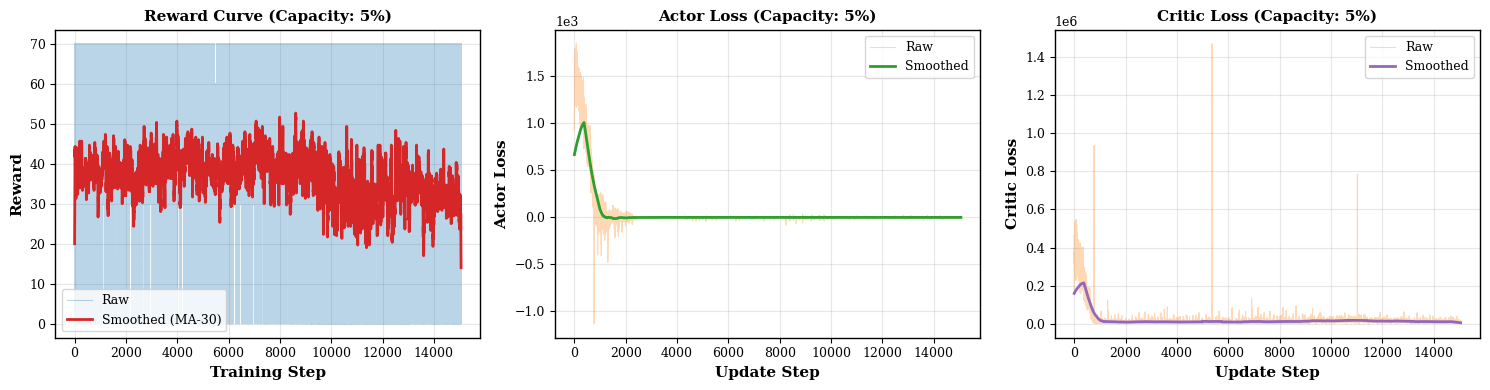


Analyzing 10% capacity...


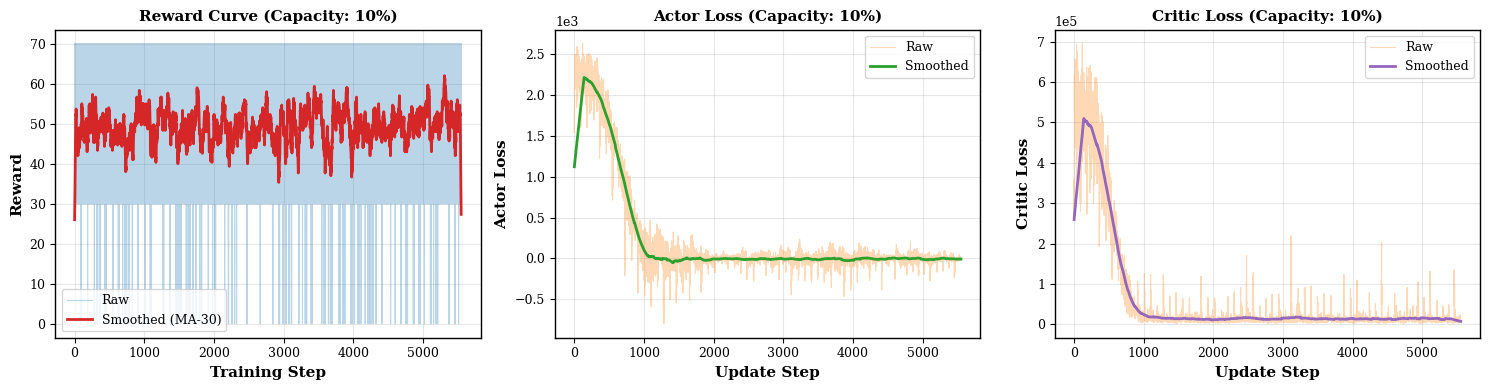


Analyzing 15% capacity...


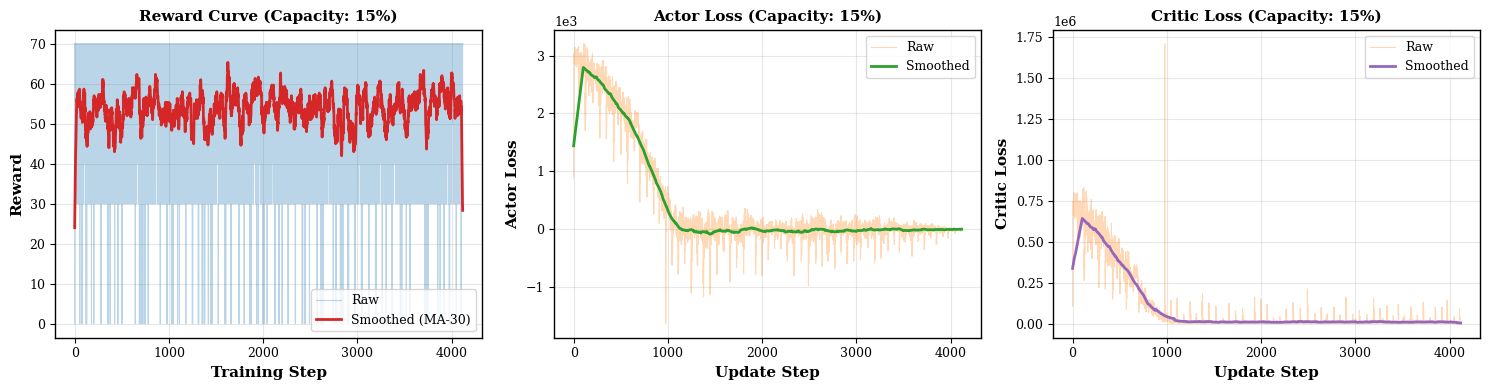


Analyzing 20% capacity...


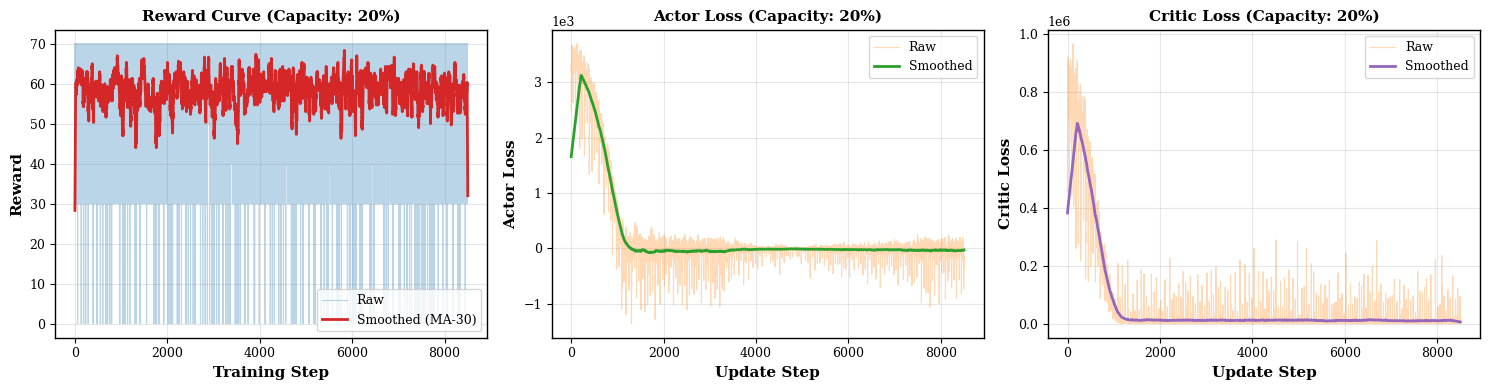

In [47]:
# =====================================================================
# A2C Algorithm Analysis: Training Dynamics & Learning Curves
# =====================================================================

def load_step_metrics(result_dir, metrics_file='metrics/step_metrics.csv'):
    """Load step-level training metrics."""
    csv_path = os.path.join(result_dir, metrics_file)
    if not os.path.exists(csv_path):
        return None
    return pd.read_csv(csv_path)

def smooth_curve(y, window=50):
    """Apply moving average smoothing to a curve."""
    if len(y) < window:
        return y
    kernel = np.ones(window) / window
    return np.convolve(y, kernel, mode='same')

# Select A2C experiments for detailed analysis
A2C_EXPERIMENTS = {
    '5%': os.path.join('..', 'Results', '2026-05-11_14-01'),
    '10%': os.path.join('..', 'Results', '2026-05-11_14-35'),
    '15%': os.path.join('..', 'Results', '2026-05-11_14-50'),
    '20%': os.path.join('..', 'Results', '2026-05-11_15-04'),
}

def plot_training_curves(experiment_dir, capacity_label):
    """Plot training metrics: reward, actor loss, critic loss."""
    step_metrics = load_step_metrics(experiment_dir)
    if step_metrics is None:
        print(f"[WARN] No step metrics found for {capacity_label}")
        return
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Reward curve
    ax = axes[0]
    y_reward = step_metrics['reward'].values
    x = np.arange(len(y_reward))
    y_smooth = smooth_curve(y_reward, window=30)
    ax.plot(x, y_reward, alpha=0.3, linewidth=0.8, color='#1f77b4', label='Raw')
    ax.plot(x, y_smooth, linewidth=2, color='#d62728', label='Smoothed (MA-30)')
    ax.set_xlabel('Training Step', fontweight='bold')
    ax.set_ylabel('Reward', fontweight='bold')
    ax.set_title(f'Reward Curve (Capacity: {capacity_label})', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Actor Loss
    ax = axes[1]
    y_actor = step_metrics['actor_loss'].dropna().values
    x_actor = np.arange(len(y_actor))
    if len(y_actor) > 0:
        y_actor_smooth = smooth_curve(y_actor, window=max(1, len(y_actor)//20))
        ax.plot(x_actor, y_actor, alpha=0.3, linewidth=0.8, color='#ff7f0e', label='Raw')
        ax.plot(x_actor, y_actor_smooth, linewidth=2, color='#2ca02c', label='Smoothed')
        ax.set_xlabel('Update Step', fontweight='bold')
        ax.set_ylabel('Actor Loss', fontweight='bold')
        ax.set_title(f'Actor Loss (Capacity: {capacity_label})', fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
    
    # Critic Loss
    ax = axes[2]
    y_critic = step_metrics['critic_loss'].dropna().values
    x_critic = np.arange(len(y_critic))
    if len(y_critic) > 0:
        y_critic_smooth = smooth_curve(y_critic, window=max(1, len(y_critic)//20))
        ax.plot(x_critic, y_critic, alpha=0.3, linewidth=0.8, color='#ff7f0e', label='Raw')
        ax.plot(x_critic, y_critic_smooth, linewidth=2, color='#9467bd', label='Smoothed')
        ax.set_xlabel('Update Step', fontweight='bold')
        ax.set_ylabel('Critic Loss', fontweight='bold')
        ax.set_title(f'Critic Loss (Capacity: {capacity_label})', fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
    
    plt.tight_layout()
    plt.show()

# Plot training curves for each capacity
print("\n" + "="*70)
print("A2C TRAINING DYNAMICS ANALYSIS")
print("="*70)
for capacity, exp_dir in A2C_EXPERIMENTS.items():
    print(f"\nAnalyzing {capacity} capacity...")
    plot_training_curves(exp_dir, capacity)


A2C EPISODE-LEVEL ANALYSIS & CONVERGENCE
✓ Loaded A2C (5%): 72 episodes


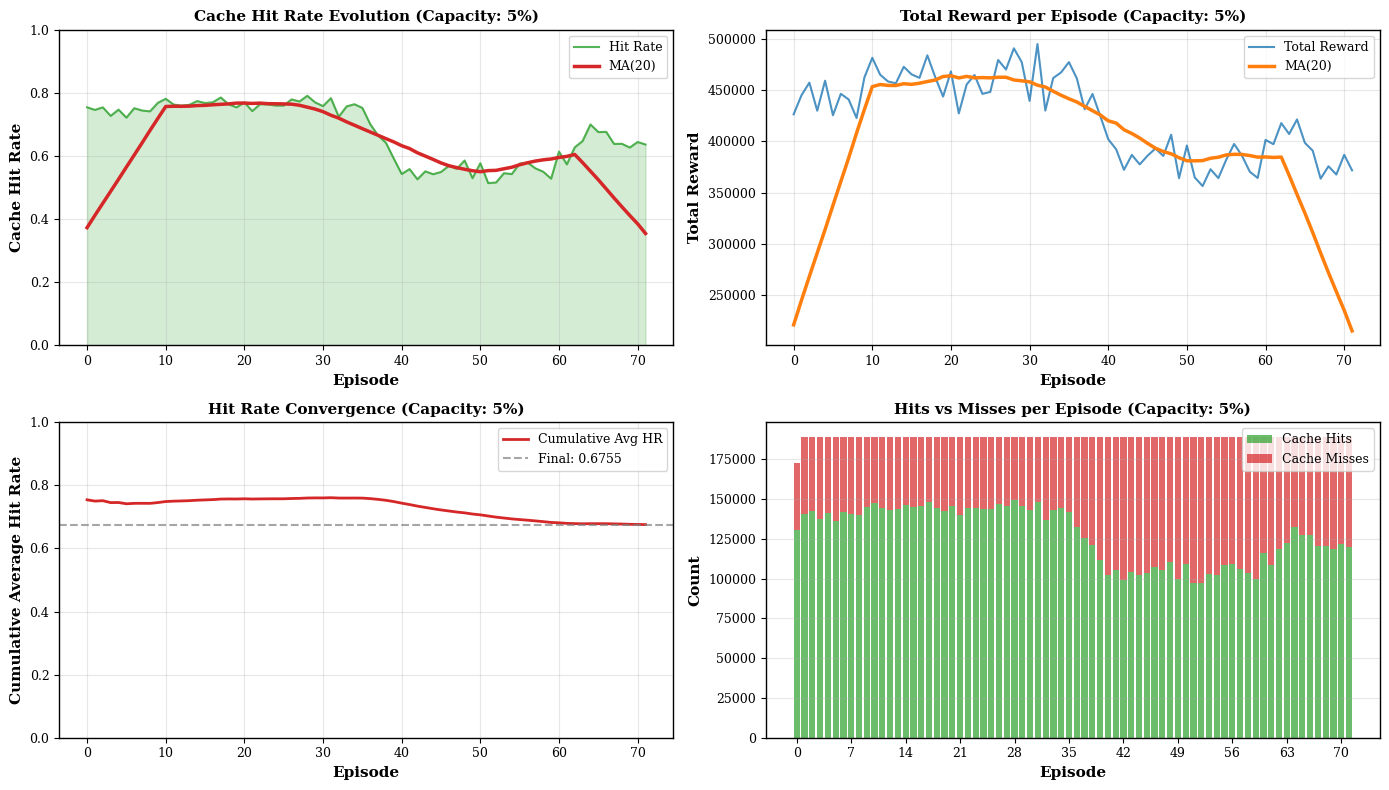


📊 Episode-Level Summary for 5% Capacity:
  • Episodes: 72
  • Hit Rate: 0.6755 ± 0.0929 (range: 0.5139 - 0.7905)
  • Total Reward: 424281.2 ± 39543.1 (range: 356320.0 - 494960.0)
  • Cache Hits: 127374.6 ± 17454.7
  • Cache Misses: 61219.2 ± 17592.2

✓ Loaded A2C (10%): 30 episodes


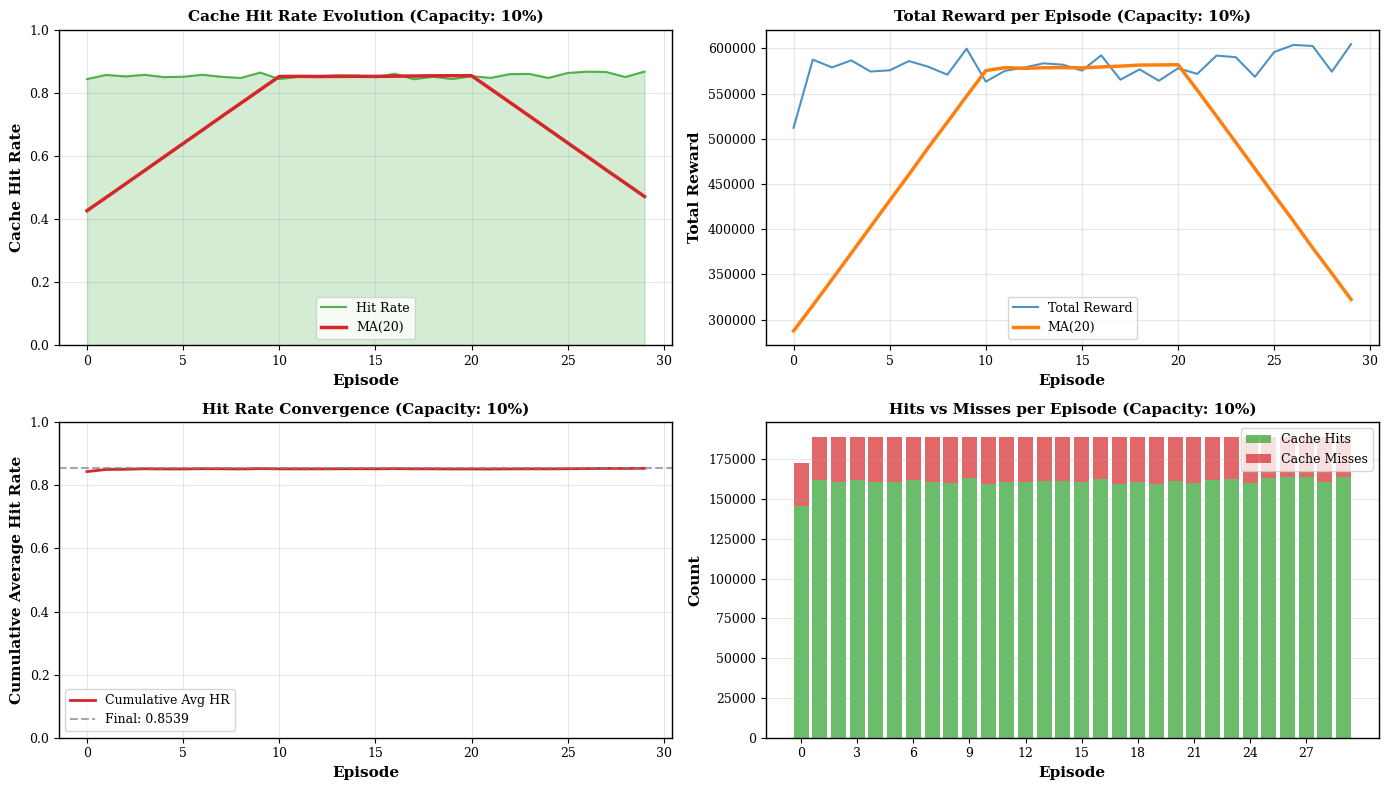


📊 Episode-Level Summary for 10% Capacity:
  • Episodes: 30
  • Hit Rate: 0.8539 ± 0.0071 (range: 0.8431 - 0.8674)
  • Total Reward: 579738.0 ± 16974.2 (range: 512300.0 - 604820.0)
  • Cache Hits: 160772.1 ± 3063.6
  • Cache Misses: 27510.6 ± 1287.1

✓ Loaded A2C (15%): 30 episodes


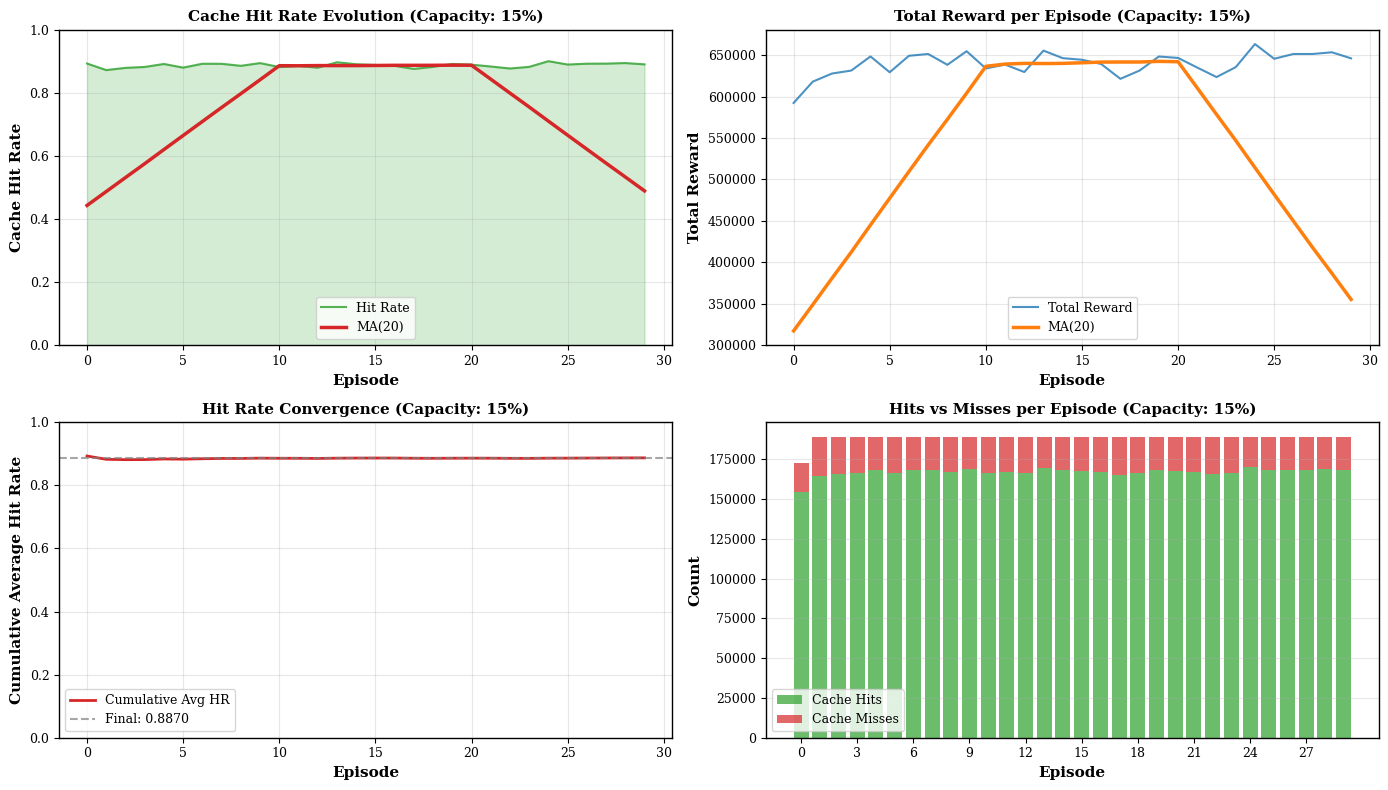


📊 Episode-Level Summary for 15% Capacity:
  • Episodes: 30
  • Hit Rate: 0.8870 ± 0.0067 (range: 0.8721 - 0.9003)
  • Total Reward: 639407.3 ± 14079.4 (range: 592250.0 - 663390.0)
  • Cache Hits: 167007.5 ± 2665.3
  • Cache Misses: 21275.1 ± 1344.8

✓ Loaded A2C (20%): 86 episodes


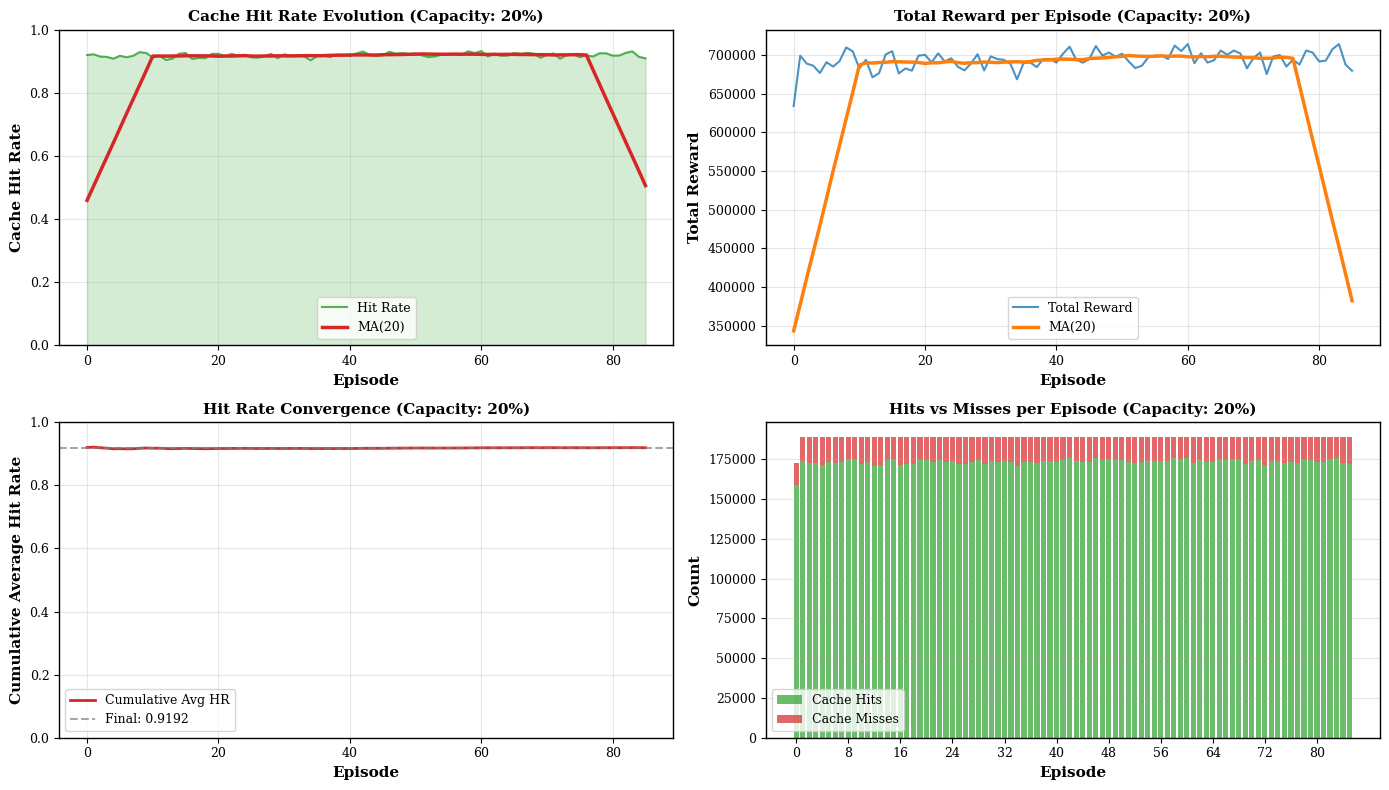


📊 Episode-Level Summary for 20% Capacity:
  • Episodes: 86
  • Hit Rate: 0.9192 ± 0.0064 (range: 0.9034 - 0.9322)
  • Total Reward: 693215.1 ± 11800.0 (range: 633930.0 - 714120.0)
  • Cache Hits: 173392.3 ± 1971.5
  • Cache Misses: 15237.7 ± 1208.5



In [48]:
# =====================================================================
# A2C Algorithm Analysis: Episode-Level Performance & Convergence
# =====================================================================

def plot_episode_metrics(episode_metrics_df, capacity_label):
    """Plot episode-level metrics: hit rate, rewards, and cumulative average."""
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    
    episodes = episode_metrics_df['episode'].values
    
    # Plot 1: Cache Hit Rate per Episode
    ax = axes[0, 0]
    hit_rate = episode_metrics_df['hit_rate'].values
    ax.plot(episodes, hit_rate, linewidth=1.5, color='#2ca02c', alpha=0.8, label='Hit Rate')
    ax.fill_between(episodes, hit_rate, alpha=0.2, color='#2ca02c')
    
    # Add moving average
    hit_rate_smooth = smooth_curve(hit_rate, window=20)
    ax.plot(episodes, hit_rate_smooth, linewidth=2.5, color='#d62728', label='MA(20)')
    
    ax.set_xlabel('Episode', fontweight='bold')
    ax.set_ylabel('Cache Hit Rate', fontweight='bold')
    ax.set_title(f'Cache Hit Rate Evolution (Capacity: {capacity_label})', fontweight='bold')
    ax.set_ylim([0, 1])
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Total Reward per Episode
    ax = axes[0, 1]
    total_reward = episode_metrics_df['total_reward'].values
    ax.plot(episodes, total_reward, linewidth=1.5, color='#1f77b4', alpha=0.8, label='Total Reward')
    
    # Add moving average
    reward_smooth = smooth_curve(total_reward, window=20)
    ax.plot(episodes, reward_smooth, linewidth=2.5, color='#ff7f0e', label='MA(20)')
    
    ax.set_xlabel('Episode', fontweight='bold')
    ax.set_ylabel('Total Reward', fontweight='bold')
    ax.set_title(f'Total Reward per Episode (Capacity: {capacity_label})', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.ticklabel_format(style='plain', axis='y')
    
    # Plot 3: Cumulative Average Hit Rate (Convergence)
    ax = axes[1, 0]
    cum_avg_hit_rate = np.cumsum(hit_rate) / (np.arange(len(hit_rate)) + 1)
    ax.plot(episodes, cum_avg_hit_rate, linewidth=2, color='#d62728', label='Cumulative Avg HR')
    ax.axhline(y=cum_avg_hit_rate[-1], color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Final: {cum_avg_hit_rate[-1]:.4f}')
    
    ax.set_xlabel('Episode', fontweight='bold')
    ax.set_ylabel('Cumulative Average Hit Rate', fontweight='bold')
    ax.set_title(f'Hit Rate Convergence (Capacity: {capacity_label})', fontweight='bold')
    ax.set_ylim([0, 1])
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 4: Cache Hits vs Misses per Episode
    ax = axes[1, 1]
    cache_hits = episode_metrics_df['cache_hits'].values
    cache_misses = episode_metrics_df['cache_misses'].values
    
    x = np.arange(len(episodes))
    width = 0.8
    
    ax.bar(x, cache_hits, width, label='Cache Hits', color='#2ca02c', alpha=0.7)
    ax.bar(x, cache_misses, width, bottom=cache_hits, label='Cache Misses', color='#d62728', alpha=0.7)
    
    ax.set_xlabel('Episode', fontweight='bold')
    ax.set_ylabel('Count', fontweight='bold')
    ax.set_title(f'Hits vs Misses per Episode (Capacity: {capacity_label})', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Adjust x-axis to show less ticks for clarity
    step = max(1, len(episodes) // 10)
    ax.set_xticks(x[::step])
    ax.set_xticklabels(episodes[::step])
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n📊 Episode-Level Summary for {capacity_label} Capacity:")
    print(f"  • Episodes: {len(episodes)}")
    print(f"  • Hit Rate: {hit_rate.mean():.4f} ± {hit_rate.std():.4f} (range: {hit_rate.min():.4f} - {hit_rate.max():.4f})")
    print(f"  • Total Reward: {total_reward.mean():.1f} ± {total_reward.std():.1f} (range: {total_reward.min():.1f} - {total_reward.max():.1f})")
    print(f"  • Cache Hits: {cache_hits.mean():.1f} ± {cache_hits.std():.1f}")
    print(f"  • Cache Misses: {cache_misses.mean():.1f} ± {cache_misses.std():.1f}")

# Analyze episode metrics for each capacity
print("\n" + "="*70)
print("A2C EPISODE-LEVEL ANALYSIS & CONVERGENCE")
print("="*70)

for capacity, exp_dir in A2C_EXPERIMENTS.items():
    episode_metrics = load_multi_scenario_metrics({capacity: {'A2C': exp_dir}}, 'metrics/episode_metrics.csv')
    if episode_metrics and capacity in episode_metrics and 'A2C' in episode_metrics[capacity]:
        df = episode_metrics[capacity]['A2C']
        plot_episode_metrics(df, capacity)
        print("")

✓ Loaded A2C (5%): 72 episodes
✓ Loaded A2C (10%): 30 episodes
✓ Loaded A2C (15%): 30 episodes
✓ Loaded A2C (20%): 86 episodes

A2C DISTRIBUTION & STATISTICAL ANALYSIS


/tmp/ipykernel_12532/3681014151.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(all_hit_rates, labels=capacities, patch_artist=True)
/tmp/ipykernel_12532/3681014151.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(all_rewards, labels=capacities, patch_artist=True)


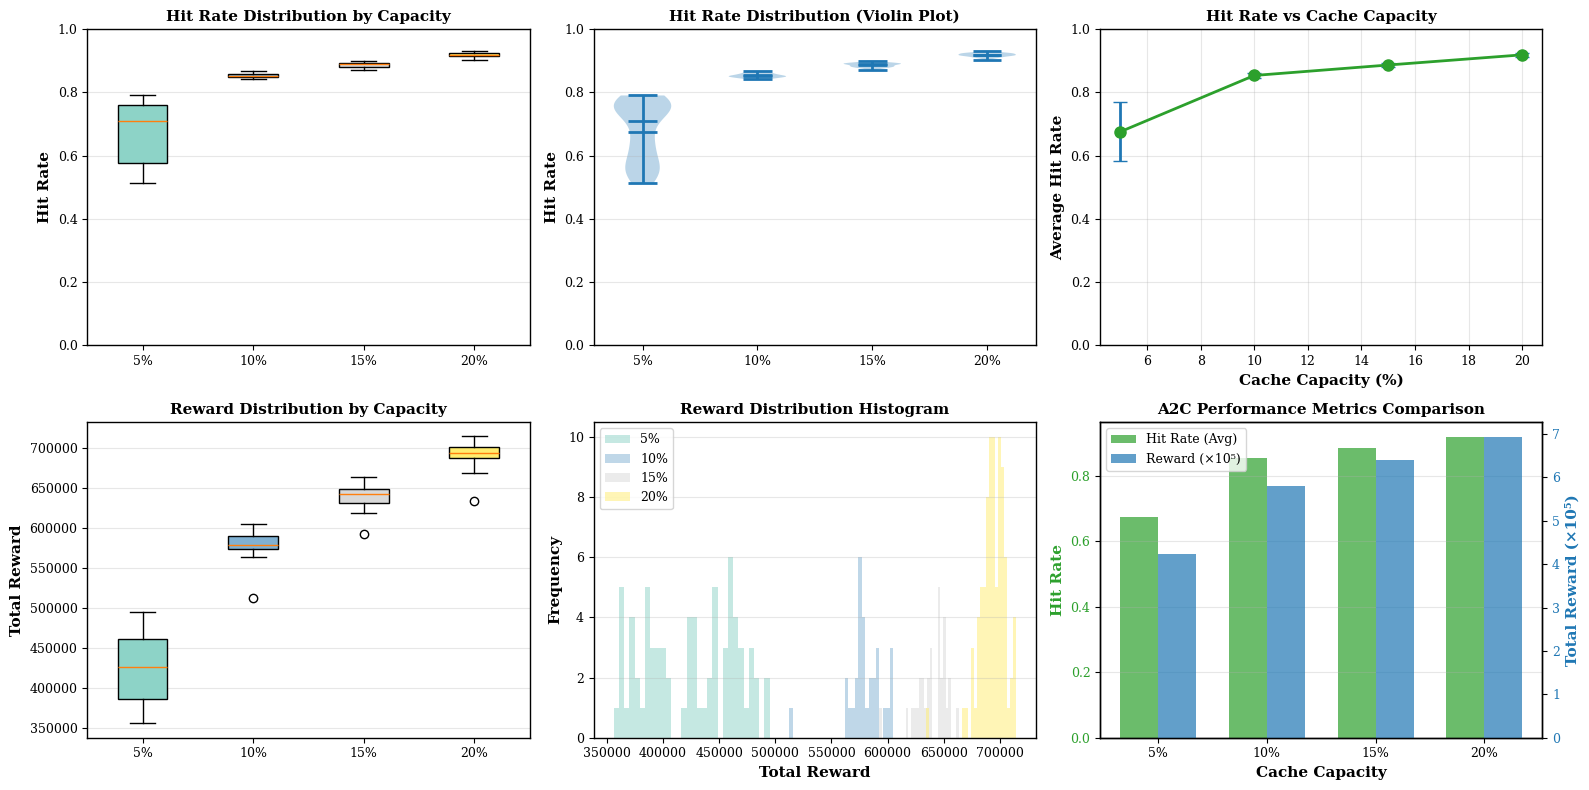


📈 Statistical Summary by Cache Capacity:
--------------------------------------------------------------------------------

5% Capacity:
  Hit Rate    → Mean: 0.6755, Median: 0.7110, Std: 0.0929
  Total Reward→ Mean: 424281.2, Median: 426800.0, Std: 39543.1

10% Capacity:
  Hit Rate    → Mean: 0.8539, Median: 0.8523, Std: 0.0071
  Total Reward→ Mean: 579738.0, Median: 578930.0, Std: 16974.2

15% Capacity:
  Hit Rate    → Mean: 0.8870, Median: 0.8888, Std: 0.0067
  Total Reward→ Mean: 639407.3, Median: 641880.0, Std: 14079.4

20% Capacity:
  Hit Rate    → Mean: 0.9192, Median: 0.9193, Std: 0.0064
  Total Reward→ Mean: 693215.1, Median: 693900.0, Std: 11800.0


In [49]:
# =====================================================================
# A2C Algorithm Analysis: Distribution & Statistical Analysis
# =====================================================================

def plot_distribution_analysis(episode_metrics_dict):
    """Plot distributions and statistical analysis of key metrics."""
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    
    capacities = sorted(episode_metrics_dict.keys(), key=lambda x: int(x.rstrip('%')))
    colors = plt.cm.Set3(np.linspace(0, 1, len(capacities)))
    
    all_hit_rates = []
    all_rewards = []
    all_eps = []
    
    # Collect data
    for capacity in capacities:
        df = episode_metrics_dict[capacity]
        all_hit_rates.append(df['hit_rate'].values)
        all_rewards.append(df['total_reward'].values)
    
    # Plot 1: Hit Rate Distribution (Box Plot)
    ax = axes[0, 0]
    bp = ax.boxplot(all_hit_rates, labels=capacities, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    ax.set_ylabel('Hit Rate', fontweight='bold')
    ax.set_title('Hit Rate Distribution by Capacity', fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Plot 2: Hit Rate Distribution (Violin Plot)
    ax = axes[0, 1]
    parts = ax.violinplot(all_hit_rates, positions=range(len(capacities)), showmeans=True, showmedians=True)
    ax.set_ylabel('Hit Rate', fontweight='bold')
    ax.set_title('Hit Rate Distribution (Violin Plot)', fontweight='bold')
    ax.set_xticks(range(len(capacities)))
    ax.set_xticklabels(capacities)
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Plot 3: Hit Rate vs Capacity (Mean ± Std)
    ax = axes[0, 2]
    hit_rate_means = [hr.mean() for hr in all_hit_rates]
    hit_rate_stds = [hr.std() for hr in all_hit_rates]
    capacity_nums = [int(c.rstrip('%')) for c in capacities]
    
    ax.errorbar(capacity_nums, hit_rate_means, yerr=hit_rate_stds, 
                marker='o', linestyle='-', linewidth=2, markersize=8, 
                capsize=5, color='#2ca02c', ecolor='#1f77b4', elinewidth=2)
    ax.set_xlabel('Cache Capacity (%)', fontweight='bold')
    ax.set_ylabel('Average Hit Rate', fontweight='bold')
    ax.set_title('Hit Rate vs Cache Capacity', fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3)
    
    # Plot 4: Reward Distribution (Box Plot)
    ax = axes[1, 0]
    bp = ax.boxplot(all_rewards, labels=capacities, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    ax.set_ylabel('Total Reward', fontweight='bold')
    ax.set_title('Reward Distribution by Capacity', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Plot 5: Reward Distribution (Histogram)
    ax = axes[1, 1]
    for rewards, capacity, color in zip(all_rewards, capacities, colors):
        ax.hist(rewards, bins=30, alpha=0.5, label=capacity, color=color)
    ax.set_xlabel('Total Reward', fontweight='bold')
    ax.set_ylabel('Frequency', fontweight='bold')
    ax.set_title('Reward Distribution Histogram', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Plot 6: Mean Metrics Comparison
    ax = axes[1, 2]
    reward_means = [r.mean() for r in all_rewards]
    reward_stds = [r.std() for r in all_rewards]
    
    x = np.arange(len(capacities))
    width = 0.35
    
    ax2 = ax.twinx()
    
    bars1 = ax.bar(x - width/2, hit_rate_means, width, label='Hit Rate (Avg)', 
                   color='#2ca02c', alpha=0.7)
    bars2 = ax2.bar(x + width/2, np.array(reward_means)/1e5, width, label='Reward (×10⁵)', 
                    color='#1f77b4', alpha=0.7)
    
    ax.set_xlabel('Cache Capacity', fontweight='bold')
    ax.set_ylabel('Hit Rate', fontweight='bold', color='#2ca02c')
    ax2.set_ylabel('Total Reward (×10⁵)', fontweight='bold', color='#1f77b4')
    ax.set_title('A2C Performance Metrics Comparison', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(capacities)
    ax.tick_params(axis='y', labelcolor='#2ca02c')
    ax2.tick_params(axis='y', labelcolor='#1f77b4')
    
    # Add legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistical summary
    print("\n📈 Statistical Summary by Cache Capacity:")
    print("-" * 80)
    for capacity, hr, rwd in zip(capacities, all_hit_rates, all_rewards):
        print(f"\n{capacity} Capacity:")
        print(f"  Hit Rate    → Mean: {hr.mean():.4f}, Median: {np.median(hr):.4f}, Std: {hr.std():.4f}")
        print(f"  Total Reward→ Mean: {rwd.mean():.1f}, Median: {np.median(rwd):.1f}, Std: {rwd.std():.1f}")

# Prepare data for distribution analysis
A2C_DIST_DATA = {}
for capacity, exp_dir in A2C_EXPERIMENTS.items():
    episode_metrics = load_multi_scenario_metrics({capacity: {'A2C': exp_dir}}, 'metrics/episode_metrics.csv')
    if episode_metrics and capacity in episode_metrics and 'A2C' in episode_metrics[capacity]:
        A2C_DIST_DATA[capacity] = episode_metrics[capacity]['A2C']

if A2C_DIST_DATA:
    print("\n" + "="*70)
    print("A2C DISTRIBUTION & STATISTICAL ANALYSIS")
    print("="*70)
    plot_distribution_analysis(A2C_DIST_DATA)


A2C LEARNING CURVES & PERFORMANCE COMPARISON
✓ Loaded A2C (5%): 72 episodes
✓ Loaded LFU (5%): 100 episodes
✓ Loaded LRU (5%): 100 episodes
✓ Loaded FIFO (5%): 100 episodes
✓ Loaded A2C (10%): 30 episodes
✓ Loaded LFU (10%): 100 episodes
✓ Loaded LRU (10%): 100 episodes
✓ Loaded FIFO (10%): 100 episodes
✓ Loaded A2C (15%): 30 episodes
✓ Loaded LFU (15%): 100 episodes
✓ Loaded LRU (15%): 100 episodes
✓ Loaded FIFO (15%): 100 episodes
✓ Loaded A2C (20%): 86 episodes
✓ Loaded LFU (20%): 100 episodes
✓ Loaded LRU (20%): 100 episodes
✓ Loaded FIFO (20%): 100 episodes


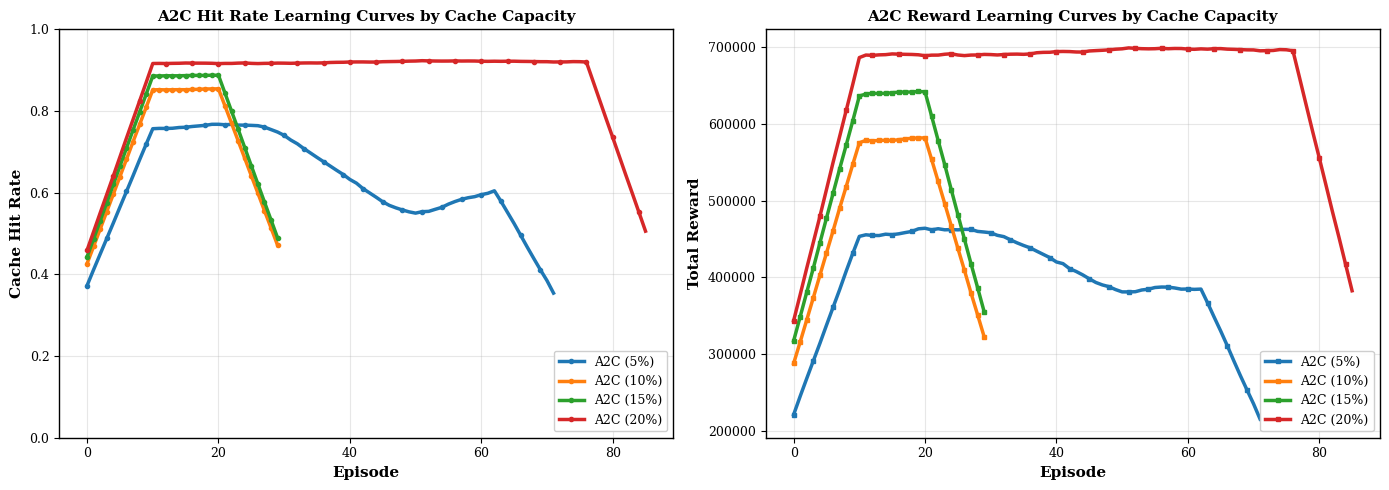


Generating performance comparison table...


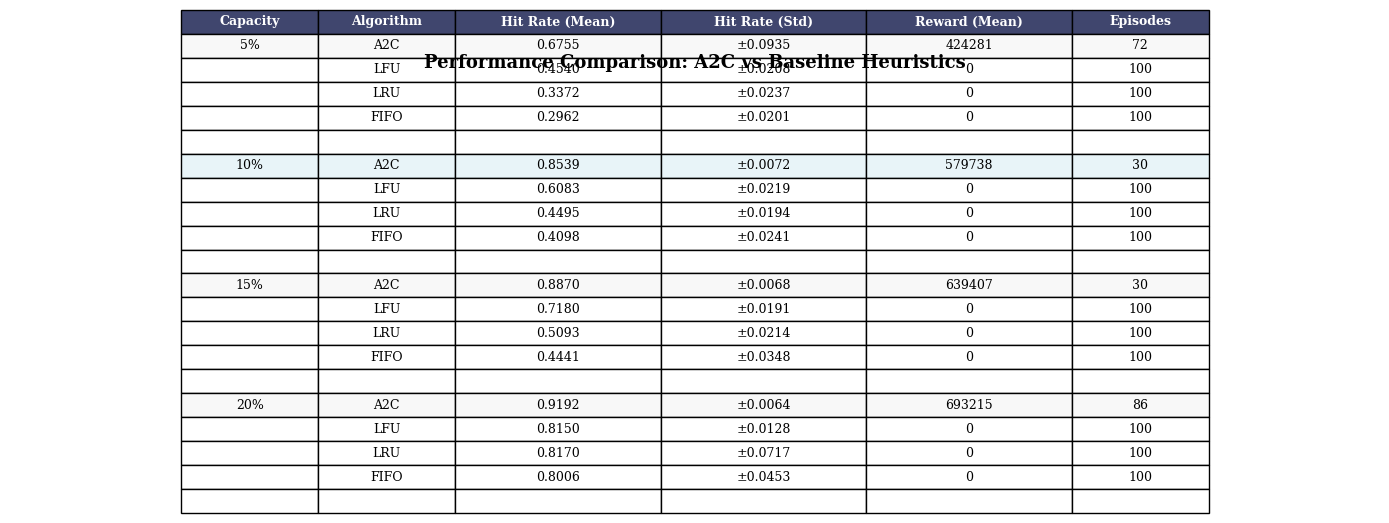


DETAILED PERFORMANCE METRICS

🎯 5% Cache Capacity:
  Hit Rate       → Mean: 0.6755, Std: 0.0935
                → Early Phase: 0.7564, Late Phase: 0.6129
                → Final: 0.6362
  Reward         → Mean: 424281.2, Std: 39820.6
                → Final: 371610.0
  Total Hits     → 9170973
  Total Misses   → 4407779
  Improvement    → -18.98% (Early→Late)

🎯 10% Cache Capacity:
  Hit Rate       → Mean: 0.8539, Std: 0.0072
                → Early Phase: 0.8525, Late Phase: 0.8601
                → Final: 0.8674
  Reward         → Mean: 579738.0, Std: 17264.4
                → Final: 604820.0
  Total Hits     → 4823163
  Total Misses   → 825317
  Improvement    → +0.88% (Early→Late)

🎯 15% Cache Capacity:
  Hit Rate       → Mean: 0.8870, Std: 0.0068
                → Early Phase: 0.8842, Late Phase: 0.8899
                → Final: 0.8903
  Reward         → Mean: 639407.3, Std: 14320.0
                → Final: 646140.0
  Total Hits     → 5010226
  Total Misses   → 638254
  Improvemen

In [54]:
# =====================================================================
# A2C Algorithm Analysis: Detailed Performance Metrics & Improvement
# =====================================================================

def calculate_performance_metrics(episode_df):
    """Calculate comprehensive performance metrics."""
    metrics = {
        'hit_rate_mean': episode_df['hit_rate'].mean(),
        'hit_rate_std': episode_df['hit_rate'].std(),
        'hit_rate_final': episode_df['hit_rate'].iloc[-1],
        'hit_rate_early': episode_df['hit_rate'].iloc[:len(episode_df)//4].mean(),
        'hit_rate_late': episode_df['hit_rate'].iloc[3*len(episode_df)//4:].mean(),
        'reward_mean': episode_df['total_reward'].mean(),
        'reward_std': episode_df['total_reward'].std(),
        'reward_final': episode_df['total_reward'].iloc[-1],
        'cache_hits_total': episode_df['cache_hits'].sum(),
        'cache_misses_total': episode_df['cache_misses'].sum(),
    }
    return metrics

def plot_learning_curves_comparison(a2c_data, heuristic_baselines):
    """Plot A2C learning curves compared to baseline heuristics."""
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    capacities = sorted(a2c_data.keys(), key=lambda x: int(x.rstrip('%')))
    
    # Plot 1: Hit Rate Learning Curves
    ax = axes[0]
    for capacity in capacities:
        df = a2c_data[capacity]
        episodes = df['episode'].values
        hit_rate = df['hit_rate'].values
        hit_rate_smooth = smooth_curve(hit_rate, window=20)
        
        capacity_num = int(capacity.rstrip('%'))
        ax.plot(episodes, hit_rate_smooth, linewidth=2.5, label=f'A2C ({capacity})', marker='o', markersize=3, markevery=max(1, len(episodes)//20))
    
    ax.set_xlabel('Episode', fontweight='bold', fontsize=11)
    ax.set_ylabel('Cache Hit Rate', fontweight='bold', fontsize=11)
    ax.set_title('A2C Hit Rate Learning Curves by Cache Capacity', fontweight='bold')
    ax.set_ylim([0, 1])
    ax.legend(loc='lower right', framealpha=0.95)
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Reward Learning Curves
    ax = axes[1]
    for capacity in capacities:
        df = a2c_data[capacity]
        episodes = df['episode'].values
        reward = df['total_reward'].values
        reward_smooth = smooth_curve(reward, window=20)
        
        ax.plot(episodes, reward_smooth, linewidth=2.5, label=f'A2C ({capacity})', marker='s', markersize=3, markevery=max(1, len(episodes)//20))
    
    ax.set_xlabel('Episode', fontweight='bold', fontsize=11)
    ax.set_ylabel('Total Reward', fontweight='bold', fontsize=11)
    ax.set_title('A2C Reward Learning Curves by Cache Capacity', fontweight='bold')
    ax.legend(loc='lower right', framealpha=0.95)
    ax.grid(True, alpha=0.3)
    ax.ticklabel_format(style='plain', axis='y')
    
    plt.tight_layout()
    plt.show()

def plot_performance_comparison_table(a2c_data, heuristics_data):
    """Create a comprehensive performance comparison visualization."""
    
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.axis('off')
    
    capacities = sorted(a2c_data.keys(), key=lambda x: int(x.rstrip('%')))
    
    # Prepare data
    table_data = []
    header = ['Capacity', 'Algorithm', 'Hit Rate (Mean)', 'Hit Rate (Std)', 'Reward (Mean)', 'Episodes']
    
    for capacity in capacities:
        # A2C data
        a2c_df = a2c_data[capacity]
        a2c_metrics = calculate_performance_metrics(a2c_df)
        table_data.append([
            capacity,
            'A2C',
            f"{a2c_metrics['hit_rate_mean']:.4f}",
            f"±{a2c_metrics['hit_rate_std']:.4f}",
            f"{a2c_metrics['reward_mean']:.0f}",
            len(a2c_df)
        ])
        
        # Heuristics data
        if capacity in heuristics_data:
            for heur_name, heur_df in heuristics_data[capacity].items():
                if heur_name != 'A2C':
                    heur_metrics = calculate_performance_metrics(heur_df)
                    table_data.append([
                        '',
                        heur_name,
                        f"{heur_metrics['hit_rate_mean']:.4f}",
                        f"±{heur_metrics['hit_rate_std']:.4f}",
                        f"{heur_metrics['reward_mean']:.0f}",
                        len(heur_df)
                    ])
        table_data.append(['', '', '', '', '', ''])  # Empty row for spacing
    
    # Create table
    table = ax.table(cellText=table_data, colLabels=header, cellLoc='center', loc='center',
                     colWidths=[0.1, 0.1, 0.15, 0.15, 0.15, 0.1])
    
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)
    
    # Style header
    for i in range(len(header)):
        table[(0, i)].set_facecolor('#40466e')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    # Alternate row colors
    for i in range(1, len(table_data) + 1):
        for j in range(len(header)):
            if table_data[i-1][0] == '':  # Spacing row
                table[(i, j)].set_facecolor('#ffffff')
            elif i % 6 == 0:  # A2C rows
                table[(i, j)].set_facecolor('#e8f4f8')
            else:
                table[(i, j)].set_facecolor('#f8f8f8')
    
    plt.title('Performance Comparison: A2C vs Baseline Heuristics', fontweight='bold', fontsize=13, pad=20)
    plt.tight_layout()
    plt.show()

# Generate comparison plots
print("\n" + "="*70)
print("A2C LEARNING CURVES & PERFORMANCE COMPARISON")
print("="*70)

# Load all heuristics data
ALL_HEURISTICS_DATA = load_multi_scenario_metrics(CAPACITY_SCENARIOS)

# Plot learning curves
plot_learning_curves_comparison(A2C_DIST_DATA, ALL_HEURISTICS_DATA)

# Plot comparison table
print("\nGenerating performance comparison table...")
plot_performance_comparison_table(A2C_DIST_DATA, ALL_HEURISTICS_DATA)

# Print detailed metrics
print("\n" + "="*70)
print("DETAILED PERFORMANCE METRICS")
print("="*70)

for capacity in sorted(A2C_DIST_DATA.keys(), key=lambda x: int(x.rstrip('%'))):
    metrics = calculate_performance_metrics(A2C_DIST_DATA[capacity])
    print(f"\n🎯 {capacity} Cache Capacity:")
    print(f"  Hit Rate       → Mean: {metrics['hit_rate_mean']:.4f}, Std: {metrics['hit_rate_std']:.4f}")
    print(f"                → Early Phase: {metrics['hit_rate_early']:.4f}, Late Phase: {metrics['hit_rate_late']:.4f}")
    print(f"                → Final: {metrics['hit_rate_final']:.4f}")
    print(f"  Reward         → Mean: {metrics['reward_mean']:.1f}, Std: {metrics['reward_std']:.1f}")
    print(f"                → Final: {metrics['reward_final']:.1f}")
    print(f"  Total Hits     → {int(metrics['cache_hits_total'])}")
    print(f"  Total Misses   → {int(metrics['cache_misses_total'])}")
    improvement = (metrics['hit_rate_late'] - metrics['hit_rate_early']) / metrics['hit_rate_early'] * 100
    print(f"  Improvement    → {improvement:+.2f}% (Early→Late)")


A2C LEARNING CURVES & PERFORMANCE COMPARISON


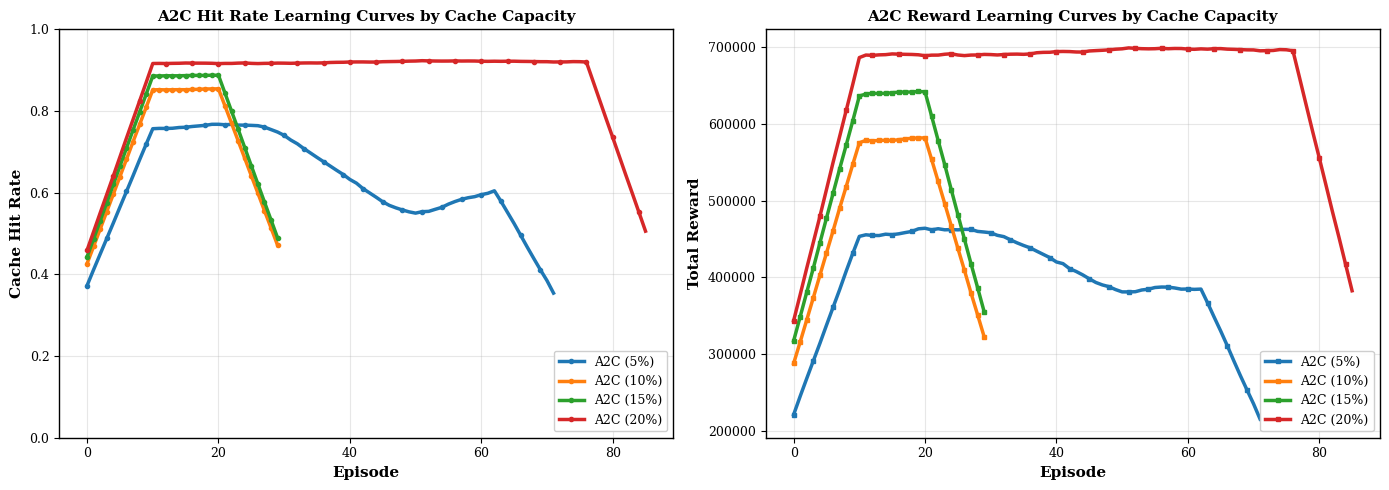


Generating performance comparison table...


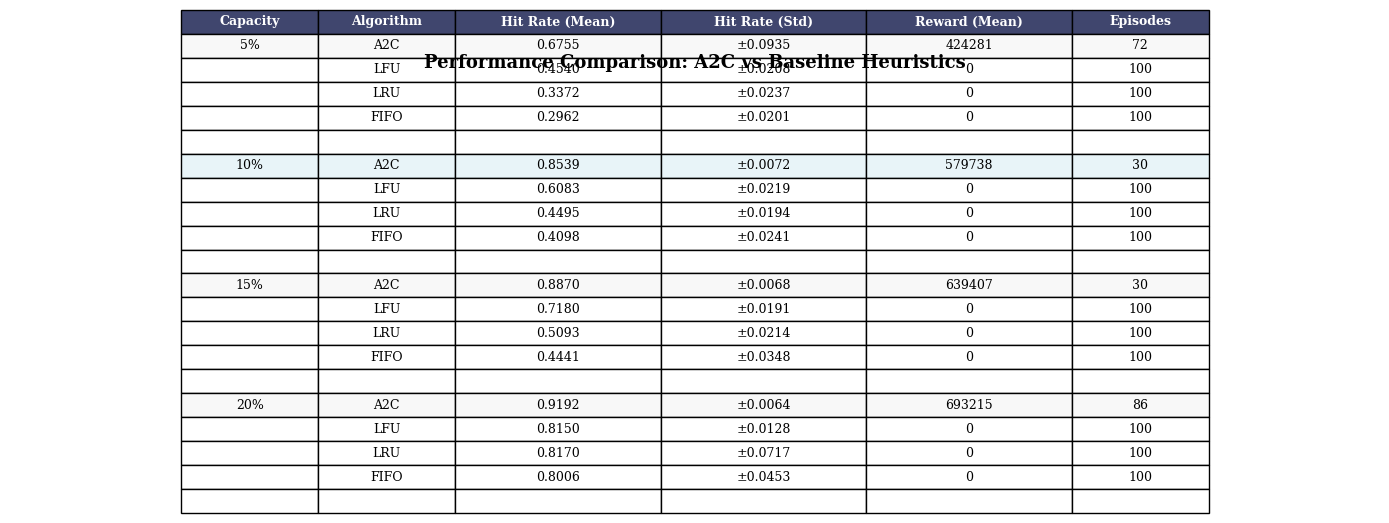


DETAILED PERFORMANCE METRICS

🎯 5% Cache Capacity:
  Hit Rate       → Mean: 0.6755, Std: 0.0935
                → Early Phase: 0.7564, Late Phase: 0.6129
                → Final: 0.6362
  Reward         → Mean: 424281.2, Std: 39820.6
                → Final: 371610.0
  Total Hits     → 9170973
  Total Misses   → 4407779
  Improvement    → -18.98% (Early→Late)

🎯 10% Cache Capacity:
  Hit Rate       → Mean: 0.8539, Std: 0.0072
                → Early Phase: 0.8525, Late Phase: 0.8601
                → Final: 0.8674
  Reward         → Mean: 579738.0, Std: 17264.4
                → Final: 604820.0
  Total Hits     → 4823163
  Total Misses   → 825317
  Improvement    → +0.88% (Early→Late)

🎯 15% Cache Capacity:
  Hit Rate       → Mean: 0.8870, Std: 0.0068
                → Early Phase: 0.8842, Late Phase: 0.8899
                → Final: 0.8903
  Reward         → Mean: 639407.3, Std: 14320.0
                → Final: 646140.0
  Total Hits     → 5010226
  Total Misses   → 638254
  Improvemen

In [53]:
# =====================================================================
# A2C Algorithm Analysis: Detailed Performance Metrics & Improvement
# =====================================================================

def calculate_performance_metrics(episode_df):
    """Calculate comprehensive performance metrics."""
    metrics = {
        'hit_rate_mean': episode_df['hit_rate'].mean(),
        'hit_rate_std': episode_df['hit_rate'].std(),
        'hit_rate_final': episode_df['hit_rate'].iloc[-1],
        'hit_rate_early': episode_df['hit_rate'].iloc[:len(episode_df)//4].mean(),
        'hit_rate_late': episode_df['hit_rate'].iloc[3*len(episode_df)//4:].mean(),
        'reward_mean': episode_df['total_reward'].mean(),
        'reward_std': episode_df['total_reward'].std(),
        'reward_final': episode_df['total_reward'].iloc[-1],
        'cache_hits_total': episode_df['cache_hits'].sum(),
        'cache_misses_total': episode_df['cache_misses'].sum(),
    }
    return metrics

def plot_learning_curves_comparison(a2c_data, heuristic_baselines):
    """Plot A2C learning curves compared to baseline heuristics."""
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    capacities = sorted(a2c_data.keys(), key=lambda x: int(x.rstrip('%')))
    
    # Plot 1: Hit Rate Learning Curves
    ax = axes[0]
    for capacity in capacities:
        df = a2c_data[capacity]
        episodes = df['episode'].values
        hit_rate = df['hit_rate'].values
        hit_rate_smooth = smooth_curve(hit_rate, window=20)
        
        capacity_num = int(capacity.rstrip('%'))
        ax.plot(episodes, hit_rate_smooth, linewidth=2.5, label=f'A2C ({capacity})', marker='o', markersize=3, markevery=max(1, len(episodes)//20))
    
    ax.set_xlabel('Episode', fontweight='bold', fontsize=11)
    ax.set_ylabel('Cache Hit Rate', fontweight='bold', fontsize=11)
    ax.set_title('A2C Hit Rate Learning Curves by Cache Capacity', fontweight='bold')
    ax.set_ylim([0, 1])
    ax.legend(loc='lower right', framealpha=0.95)
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Reward Learning Curves
    ax = axes[1]
    for capacity in capacities:
        df = a2c_data[capacity]
        episodes = df['episode'].values
        reward = df['total_reward'].values
        reward_smooth = smooth_curve(reward, window=20)
        
        ax.plot(episodes, reward_smooth, linewidth=2.5, label=f'A2C ({capacity})', marker='s', markersize=3, markevery=max(1, len(episodes)//20))
    
    ax.set_xlabel('Episode', fontweight='bold', fontsize=11)
    ax.set_ylabel('Total Reward', fontweight='bold', fontsize=11)
    ax.set_title('A2C Reward Learning Curves by Cache Capacity', fontweight='bold')
    ax.legend(loc='lower right', framealpha=0.95)
    ax.grid(True, alpha=0.3)
    ax.ticklabel_format(style='plain', axis='y')
    
    plt.tight_layout()
    plt.show()

def plot_performance_comparison_table(a2c_data, heuristics_data):
    """Create a comprehensive performance comparison visualization."""
    
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.axis('off')
    
    capacities = sorted(a2c_data.keys(), key=lambda x: int(x.rstrip('%')))
    
    # Prepare data
    table_data = []
    header = ['Capacity', 'Algorithm', 'Hit Rate (Mean)', 'Hit Rate (Std)', 'Reward (Mean)', 'Episodes']
    
    for capacity in capacities:
        # A2C data
        a2c_df = a2c_data[capacity]
        a2c_metrics = calculate_performance_metrics(a2c_df)
        table_data.append([
            capacity,
            'A2C',
            f"{a2c_metrics['hit_rate_mean']:.4f}",
            f"±{a2c_metrics['hit_rate_std']:.4f}",
            f"{a2c_metrics['reward_mean']:.0f}",
            len(a2c_df)
        ])
        
        # Heuristics data
        if capacity in heuristics_data:
            for heur_name, heur_df in heuristics_data[capacity].items():
                if heur_name != 'A2C':
                    heur_metrics = calculate_performance_metrics(heur_df)
                    table_data.append([
                        '',
                        heur_name,
                        f"{heur_metrics['hit_rate_mean']:.4f}",
                        f"±{heur_metrics['hit_rate_std']:.4f}",
                        f"{heur_metrics['reward_mean']:.0f}",
                        len(heur_df)
                    ])
        table_data.append(['', '', '', '', '', ''])  # Empty row for spacing
    
    # Create table
    table = ax.table(cellText=table_data, colLabels=header, cellLoc='center', loc='center',
                     colWidths=[0.1, 0.1, 0.15, 0.15, 0.15, 0.1])
    
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)
    
    # Style header
    for i in range(len(header)):
        table[(0, i)].set_facecolor('#40466e')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    # Alternate row colors
    for i in range(1, len(table_data) + 1):
        for j in range(len(header)):
            if table_data[i-1][0] == '':  # Spacing row
                table[(i, j)].set_facecolor('#ffffff')
            elif i % 6 == 0:  # A2C rows
                table[(i, j)].set_facecolor('#e8f4f8')
            else:
                table[(i, j)].set_facecolor('#f8f8f8')
    
    plt.title('Performance Comparison: A2C vs Baseline Heuristics', fontweight='bold', fontsize=13, pad=20)
    plt.tight_layout()
    plt.show()

# Generate comparison plots
print("\n" + "="*70)
print("A2C LEARNING CURVES & PERFORMANCE COMPARISON")
print("="*70)

# Use already loaded capacity_scenarios_data from previous cells
ALL_HEURISTICS_DATA = capacity_scenarios_data

# Plot learning curves
plot_learning_curves_comparison(A2C_DIST_DATA, ALL_HEURISTICS_DATA)

# Plot comparison table
print("\nGenerating performance comparison table...")
plot_performance_comparison_table(A2C_DIST_DATA, ALL_HEURISTICS_DATA)

# Print detailed metrics
print("\n" + "="*70)
print("DETAILED PERFORMANCE METRICS")
print("="*70)

for capacity in sorted(A2C_DIST_DATA.keys(), key=lambda x: int(x.rstrip('%'))):
    metrics = calculate_performance_metrics(A2C_DIST_DATA[capacity])
    print(f"\n🎯 {capacity} Cache Capacity:")
    print(f"  Hit Rate       → Mean: {metrics['hit_rate_mean']:.4f}, Std: {metrics['hit_rate_std']:.4f}")
    print(f"                → Early Phase: {metrics['hit_rate_early']:.4f}, Late Phase: {metrics['hit_rate_late']:.4f}")
    print(f"                → Final: {metrics['hit_rate_final']:.4f}")
    print(f"  Reward         → Mean: {metrics['reward_mean']:.1f}, Std: {metrics['reward_std']:.1f}")
    print(f"                → Final: {metrics['reward_final']:.1f}")
    print(f"  Total Hits     → {int(metrics['cache_hits_total'])}")
    print(f"  Total Misses   → {int(metrics['cache_misses_total'])}")
    improvement = (metrics['hit_rate_late'] - metrics['hit_rate_early']) / metrics['hit_rate_early'] * 100
    print(f"  Improvement    → {improvement:+.2f}% (Early→Late)")